## **Libraries**

In [2]:
import numpy as np
import pandas as pd
import os
import cv2
from pathlib import Path
import torch.nn.functional as F
import torch.nn as nn
import torch
import albumentations as A
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import ReduceLROnPlateau
import warnings
import random
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

device = "cuda" if torch.cuda.is_available() else "cpu"
set_seed()
warnings.filterwarnings("ignore")

In [3]:
CONFIG = {
    "Height": 256,
    "Width": 1600,
    "n_classes": 4,
    "val_split": 0.2,
    "batch_size": 8,
    "num_workers": 2,
    "epochs": 100,
    "lr": 1e-4,
    "Seed": 42,
    "THRESHOLD": 0.5,
    "n_channels": 3
}

DATA_DIR = Path("./Dataset")
TRAIN_DIR = DATA_DIR / "train_images"
TEST_DIR = DATA_DIR / "test_images"
TRAIN_CSV = DATA_DIR / "train.csv"
WORK_DIR = Path("./outputs")

## Data

In [4]:
cd ..

/Users/thachphung/Documents/Graduation Project


In [5]:
df = pd.read_csv(TRAIN_CSV)
print(len(df))
df.info()

7095
<class 'pandas.DataFrame'>
RangeIndex: 7095 entries, 0 to 7094
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   ImageId        7095 non-null   str  
 1   ClassId        7095 non-null   int64
 2   EncodedPixels  7095 non-null   str  
dtypes: int64(1), str(2)
memory usage: 166.4 KB


In [6]:
df.head(10)

,ImageId,ClassId,EncodedPixels
0,0002cc93b.jpg,1,29102 12 29346 24 29602 24 29858 24 30114 24 3...
1,0007a71bf.jpg,3,18661 28 18863 82 19091 110 19347 110 19603 11...
2,000a4bcdd.jpg,1,37607 3 37858 8 38108 14 38359 20 38610 25 388...
3,000f6bf48.jpg,4,131973 1 132228 4 132483 6 132738 8 132993 11 ...
4,0014fce06.jpg,3,229501 11 229741 33 229981 55 230221 77 230468...
5,0025bde0c.jpg,3,8458 14 8707 35 8963 48 9219 71 9475 88 9731 8...
6,0025bde0c.jpg,4,315139 8 315395 15 315651 16 315906 17 316162 ...
7,002af848d.jpg,4,290800 6 291055 13 291311 15 291566 18 291822 ...
8,002fc4e19.jpg,1,146021 3 146275 10 146529 40 146783 46 147038 ...
9,002fc4e19.jpg,2,145658 7 145901 20 146144 33 146386 47 146629 ...


The number of all images is  12568
The number of all images with defect  6666
The number of all images without defect  5902


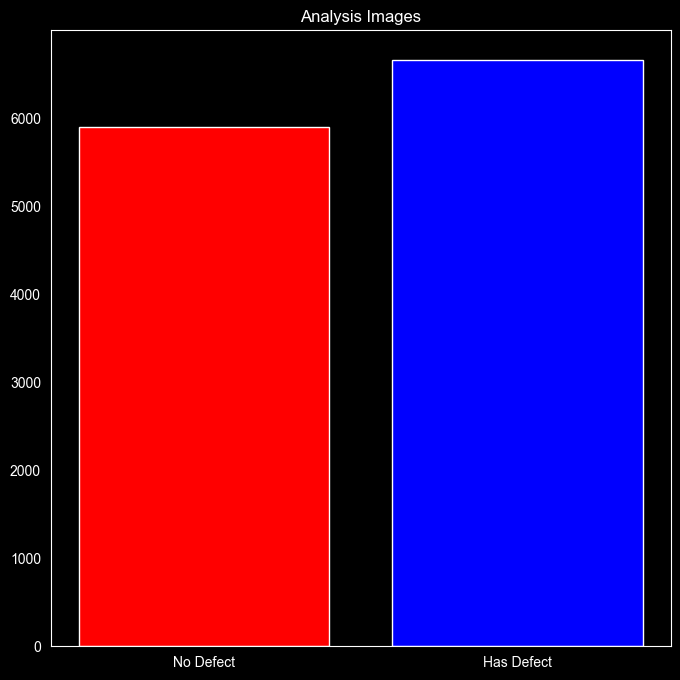

In [7]:
# Get all images from training Image
all_images = os.listdir(TRAIN_DIR)
all_images = [img for img in all_images if img.endswith((".jpg", ".png"))]

# Image id from csv
defect_images = df["ImageId"].unique().tolist()

# Image no defect
no_defect_images = set(all_images) - set(defect_images)

print("The number of all images is ", len(all_images))
print("The number of all images with defect ", len(defect_images))
print("The number of all images without defect ", len(no_defect_images))

# Bar plot
plt.figure(figsize=(8, 8))
plt.bar(["No Defect", "Has Defect"], [len(no_defect_images), len(defect_images)], color=["red", "blue"])
plt.title("Analysis Images")
plt.grid(False)
plt.show()

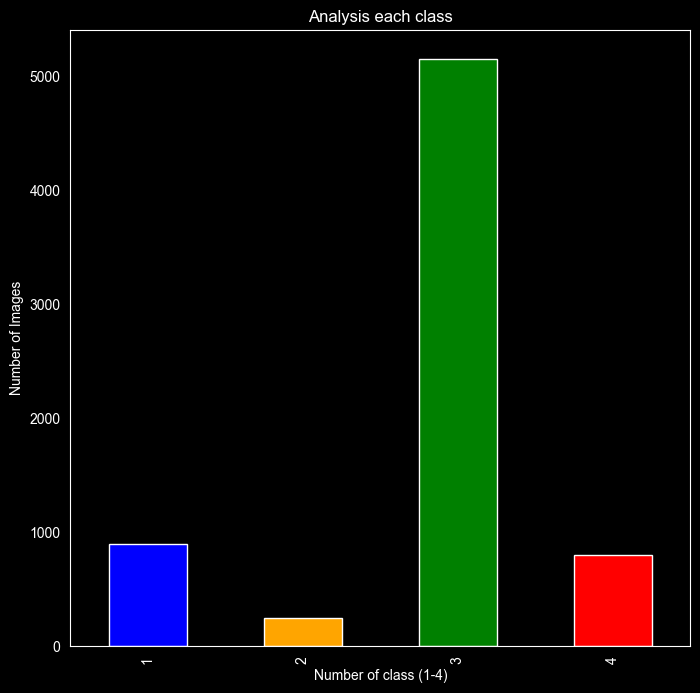

In [8]:
class_counts = (df[df["EncodedPixels"].notnull()].groupby("ClassId")["ImageId"].nunique())

# Total samples
total_images = df["ImageId"].nunique()
plt.figure(figsize=(8,8))
class_counts.plot(kind="bar", color=["blue","orange","green","red"])
plt.title("Analysis each class")
plt.ylabel("Number of Images")
plt.xlabel("Number of class (1-4)")
plt.grid(False)
plt.show()

### Preprocessing

In [9]:
class RLEprocessor:
    """RLE encoding and decoding"""

    @staticmethod
    def rle_decoder(rle_str, shape=(CONFIG['Height'], CONFIG['Width'])) -> np.ndarray:
        rle_list = rle_str.split()  # convert to list
        assert isinstance(rle_list, list)  # if is list, be passed
        start, length = [np.asarray(x, dtype=int) for x in (rle_list[0::2], rle_list[1::2])]
        # start = [rle_list[x] - 1 for x in range(0, len(rle_list), 2)]
        # length = [rle_list[x] for x in range(1, len(rle_list), 2)]
        start -= 1
        ends = start + length
        image = np.zeros(shape[0] * shape[1], dtype=np.uint8)
        for start, end in zip(start, ends):
            image[start:end] = 1
        return image.reshape(shape, order='F')

    @staticmethod
    def build_masks(df: pd.DataFrame, image_id: str) -> np.ndarray:
        mask = np.zeros((CONFIG["Height"], CONFIG['Width'], CONFIG['n_classes']), dtype=np.uint8)

        for i in range(1, 5):
            rle = df.loc[
                (df["ImageId"] == image_id) & (df['ClassId']== i), "EncodedPixels"
            ]
            if len(rle) > 0:
                rle = rle.values[0]
                if pd.notna(rle):
                    mask[:,:, i-1] = RLEprocessor.rle_decoder(rle)
        return mask

    @staticmethod
    def rle_encoder(mask):
        pixels = mask.T.flatten(order='F')
        pixels = np.concatenate([[0], pixels, [0]])
        runs = np.where(pixels[1:] != pixels[:-1])[0] + 1  # Use 0 to covert tuple to nparray
        runs[1::2] -= runs[::2]
        return ' '.join(str(x) for x in runs)

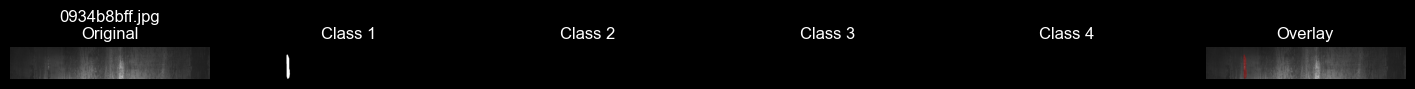

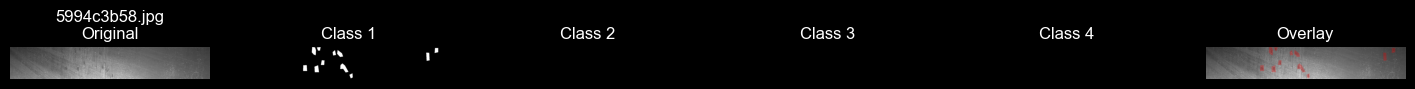

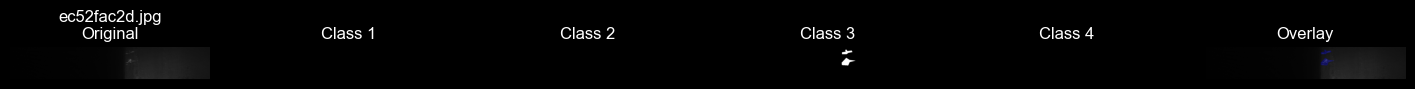

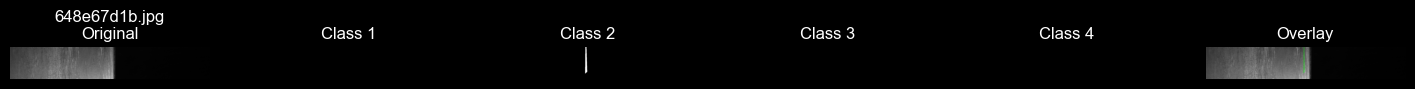

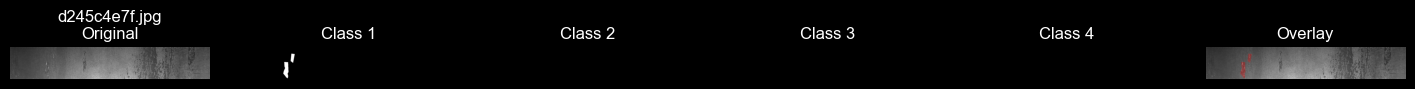

In [10]:
sample_images = df["ImageId"].drop_duplicates().sample(5, random_state=42).tolist()

for image_id in sample_images:
    img_path = TRAIN_DIR / image_id
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    masks = RLEprocessor.build_masks(df, image_id)

    plt.figure(figsize=(18,4))
    plt.subplot(1,6,1)
    plt.imshow(img)
    plt.title(f"{image_id}\nOriginal")
    plt.axis("off")

    # Sınıf maskeleri
    for i in range(4):
        plt.subplot(1,6,i+2)
        plt.imshow(masks[..., i], cmap="gray")
        plt.title(f"Class {i+1}")
        plt.axis("off")

    # Overlay
    overlay = img.copy()
    colors = [(255,0,0), (0,255,0), (0,0,255), (255,255,0)]  # R, G, B, Sarı
    for i in range(4):
        mask = masks[..., i].astype(bool)
        overlay[mask] = (0.7*overlay[mask] + 0.3*np.array(colors[i])).astype(np.uint8)

    plt.subplot(1,6,6)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

    plt.show()

### Augmentation

In [11]:
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
        A.Affine(scale=(0.9,1.1), translate_percent=(0.02,0.02), rotate=(-5,5), p=0.5),
        A.GaussianBlur(blur_limit=(3, 7), p=0.2),
        A.RandomBrightnessContrast(p=0.4),
        A.Resize(CONFIG['Height'], CONFIG["Width"], interpolation=1),
        A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
        ToTensorV2(),
    ], is_check_shapes=False)
val_transform = A.Compose([
        A.Resize(CONFIG['Height'], CONFIG["Width"], interpolation=1),
        A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
        ToTensorV2(),
    ])

### Build data

In [12]:
class SteverstalDataset(Dataset):
    """PyTorch Dataset for Severstal"""

    def __init__(self, image_ids, df: pd.DataFrame, image_dir, transform=None, load_rgb=True):
        self.df = df
        self.image_dir = Path(image_dir)
        self.image_ids= list(image_ids)
        self.transform = transform
        self.load_rgb = load_rgb

    def __len__(self):
        return len(self.image_ids)

    def _read_image(self, image_id):
        img = cv2.imread(str(self.image_dir / image_id), cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(f"Image not found: {image_id}")
        if self.load_rgb:
            img = np.repeat(img[..., None], 3, axis=2)  # (H,W,3)
        return img


    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        image = self._read_image(image_id)
        mask = RLEprocessor.build_masks(self.df, image_id)

        if self.transform:
            output = self.transform(image=image, mask=mask)
            image, mask = output['image'], output['mask'].permute(2, 0, 1) # (C, H, W)
        else:
            image = torch.from_numpy(image.transpose(2,0,1)).float()
            mask = torch.from_numpy(mask.transpose(2,0,1)).float()

        meta = {"image_id": image_id}
        return {
            'image': image,   # (3, H, W)
            'mask': mask,     # (4, H, W)
            'meta': meta
        }


# --- Collate function ---
def collate_fn(batch):
    images, masks, metas = zip(*batch)
    images = torch.stack(images)
    masks = torch.stack(masks)
    return images, masks, metas

In [101]:
import torch
from torch.utils.data import Dataset
import cv2
import numpy as np
from pathlib import Path

class SeverstalTestDataset(Dataset):
    """Dataset for test"""

    def __init__(self, image_dir, transform=None, load_rgb=True):
        self.image_dir = Path(image_dir)
        self.transform = transform
        self.load_rgb = load_rgb

        # Get all images
        self.image_ids = sorted([
            p.name for p in self.image_dir.glob("*")
            if p.suffix.lower() in [".jpg", ".png", ".jpeg"]
        ])

    def __len__(self):
        return len(self.image_ids)

    def _read_image(self, image_id):
        img = cv2.imread(str(self.image_dir / image_id), cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(f"Image not found: {image_id}")

        if self.load_rgb:
            img = np.repeat(img[..., None], 3, axis=2)

        return img

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        image = self._read_image(image_id)

        if self.transform:
            output = self.transform(image=image)
            image = output['image']
        else:
            image = torch.from_numpy(image.transpose(2, 0, 1)).float()

        meta = {"image_id": image_id}

        return {
            'image': image,
            'meta': meta
        }

In [102]:
test_ds = SeverstalTestDataset(TEST_DIR, transform=val_transform)

In [103]:
test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=0)

In [104]:
batch = next(iter(test_loader))

In [108]:
images = batch['image'].shape

In [106]:
meta = batch['meta']

### Dataset , Dataloader

In [13]:
train_ids, valid_ids = train_test_split(
    df["ImageId"].unique(),
    test_size=CONFIG["val_split"],
    random_state=CONFIG["Seed"]
)

In [14]:
train_ds = SteverstalDataset(train_ids, df, TRAIN_DIR, transform=train_transform)
val_ds = SteverstalDataset(valid_ids, df, TRAIN_DIR, transform=val_transform)

In [15]:
train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=0)

In [16]:
batch = next(iter(train_loader))

In [17]:
images = batch['image']

In [18]:
images.shape[0]

8

In [19]:
images.shape

torch.Size([8, 3, 256, 1600])

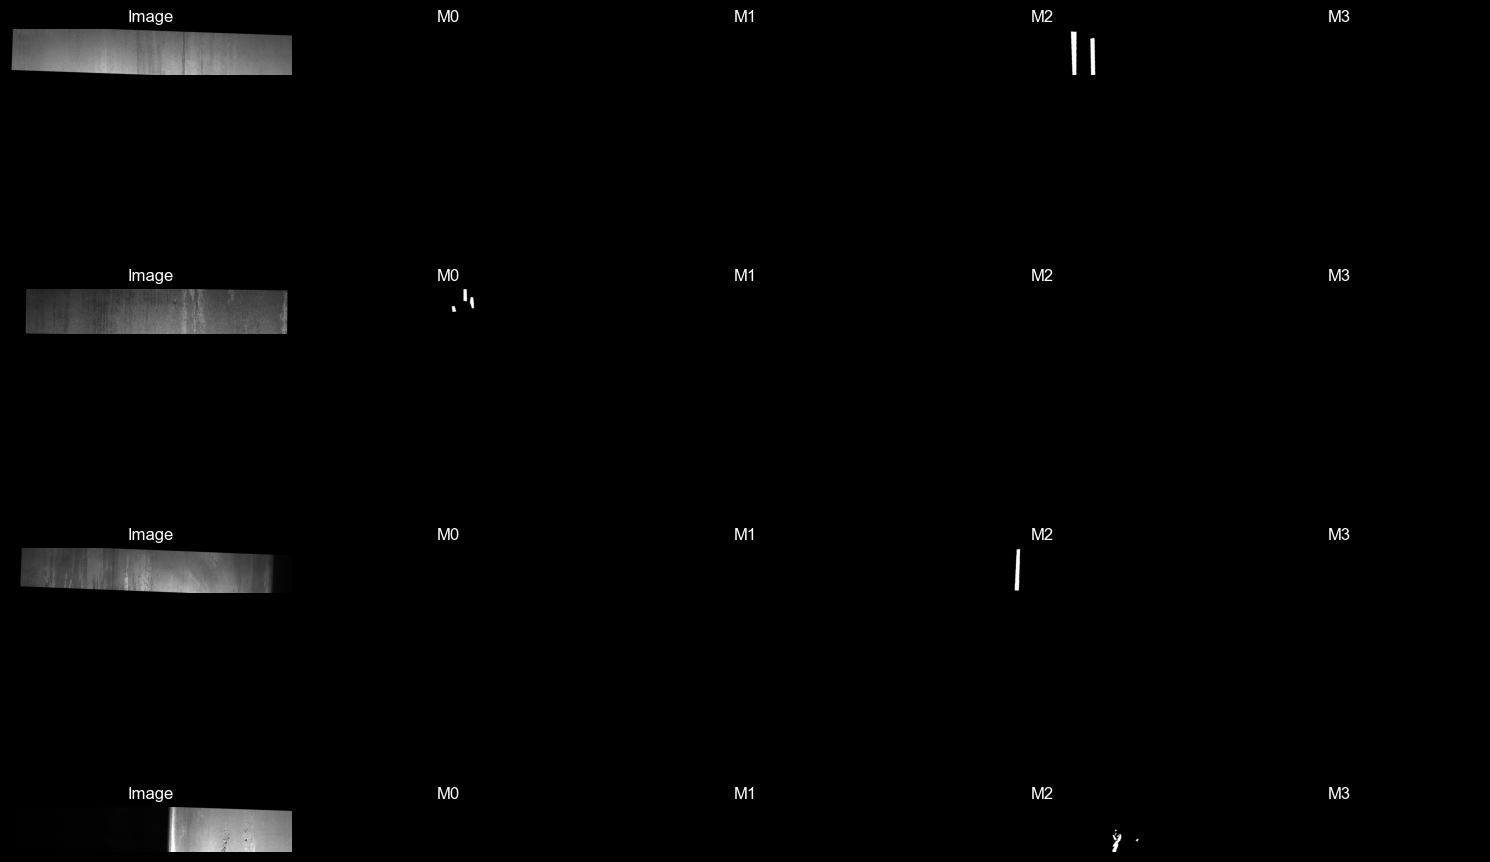

In [20]:
batch = next(iter(train_loader))
images = batch['image']
masks = batch['mask']
B = images.shape[0]  # batch size
num_show = min(4, B)  # hiển thị tối đa 4 sample

plt.figure(figsize=(15, 3 * num_show))

for i in range(num_show):
    img = images[i].cpu().numpy()[0]   # (H, W)
    mask = masks[i].cpu().numpy()      # (4, H, W)
    #print(mask[i])

    # unnormalize nếu cần
    img = (img * 0.5) + 0.5

    # ===== Image =====
    plt.subplot(num_show, 5, i*5 + 1)
    plt.imshow(img, cmap='gray')
    plt.title("Image")
    plt.axis('off')

    # ===== 4 Masks =====
    for j in range(4):
        plt.subplot(num_show, 5, i*5 + 2 + j)
        plt.imshow(mask[j,:,:], cmap='gray')
        plt.title(f"M{j}")
        plt.axis('off')

plt.tight_layout()
plt.show()

## Model

In [21]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, padding):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, padding=padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=kernel_size, padding=padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.conv_block(x)

class Encoder(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, padding):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.MaxPool2d(kernel_size=2),
            ConvBlock(in_channels, out_channels, kernel_size, padding),
        )
    def forward(self, x):
        return self.encoder(x)

class Decoder(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, padding, bilinear=True):
        super().__init__()
        if bilinear:
            self.conv_trans = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv_block = ConvBlock(in_channels, out_channels, kernel_size, padding)
        else:
            self.conv_trans = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
            self.conv_block = ConvBlock(in_channels, out_channels, kernel_size, padding)

    def forward(self, x1, x2):
        # B, C, H, W
        x1= self.conv_trans(x1)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, (diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2))
        x = torch.cat([x2, x1], dim=1) # concat by channel
        return self.conv_block(x)

class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)

    def forward(self, x):
        return self.conv(x)


In [22]:
class UNet(nn.Module):
    def __init__(self, n_channels, n_classes, bilinear=False):
        super().__init__()
        self.inc = ConvBlock(n_channels, 32, kernel_size=3, padding=1)
        self.down1 = Encoder(32, 64, 3, 1)
        self.down2 = Encoder(64, 128, 3, 1)
        self.down3 = Encoder(128, 256, 3, 1)
        factor = 2 if bilinear else 1
        self.down4 = Encoder(256, 512 // factor, 3, 1)
        self.bottom_neck = ConvBlock(512//factor, 512//factor, kernel_size=1, padding=0)
        self.up1 = Decoder(512, 256//factor, 3, 1, bilinear=bilinear)
        self.up2 = Decoder(256, 128//factor, 3, 1, bilinear=bilinear)
        self.up3 = Decoder(128, 64//factor, 3, 1, bilinear=bilinear)
        self.up4 = Decoder(64, 32, 3, 1, bilinear=bilinear)
        self.outc = OutConv(32, n_classes)

    def forward(self, x):
        x1 = self.inc(x) # 64
        x2 = self.down1(x1) # 128
        x3 = self.down2(x2) # 256
        x4 = self.down3(x3) #512
        x5 = self.down4(x4) # 1024
        x5 = self.bottom_neck(x5) # 1024
        x = self.up1(x5, x4) # 512
        x = self.up2(x, x3) # 256
        x = self.up3(x, x2) # 128
        logits = self.up4(x, x1) # 64
        return self.outc(logits)

In [23]:
model = UNet(n_channels=3, n_classes=4, bilinear=False)

In [24]:
from torchinfo import summary

summary(model, input_size=(4, 3, 256,1600 ))

Layer (type:depth-idx)                        Output Shape              Param #
UNet                                          [4, 4, 256, 1600]         --
├─ConvBlock: 1-1                              [4, 32, 256, 1600]        --
│    └─Sequential: 2-1                        [4, 32, 256, 1600]        --
│    │    └─Conv2d: 3-1                       [4, 32, 256, 1600]        864
│    │    └─BatchNorm2d: 3-2                  [4, 32, 256, 1600]        64
│    │    └─ReLU: 3-3                         [4, 32, 256, 1600]        --
│    │    └─Conv2d: 3-4                       [4, 32, 256, 1600]        9,216
│    │    └─BatchNorm2d: 3-5                  [4, 32, 256, 1600]        64
│    │    └─ReLU: 3-6                         [4, 32, 256, 1600]        --
├─Encoder: 1-2                                [4, 64, 128, 800]         --
│    └─Sequential: 2-2                        [4, 64, 128, 800]         --
│    │    └─MaxPool2d: 3-7                    [4, 32, 128, 800]         --
│    │    └─Conv

## Metrics

In [96]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0): super().__init__(); self.smooth=smooth
    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        p = probs.view(probs.size(0), probs.size(1), -1)
        t = targets.view(targets.size(0), targets.size(1), -1)
        inter = (p*t).sum(2); den = p.sum(2)+t.sum(2)
        dice = (2*inter + self.smooth) / (den + self.smooth)
        return 1.0 - dice.mean()

class WeightedFocalDiceLoss(nn.Module):
    def __init__(self, class_weights=None, gamma=2.0, lam_f=0.7, lam_d=0.3):
        super().__init__()
        self.w = class_weights
        self.g = gamma
        self.lf = lam_f
        self.ld = lam_d
        self.dice = DiceLoss()

    def forward(self, logits, targets, return_details=False):
        probs = torch.sigmoid(logits)
        eps = 1e-8

        # BCE
        bce = -(targets * torch.log(probs + eps) +
                (1 - targets) * torch.log(1 - probs + eps))

        # Focal loss
        pt = torch.where(targets == 1, probs, 1 - probs)
        fw = (1 - pt) ** self.g

        if self.w is not None:
            fw = fw * logits.new_tensor(self.w).view(1, -1, 1, 1)

        focal = (fw * bce).mean()
        dice = self.dice(logits, targets)

        loss = self.lf * focal + self.ld * dice

        if return_details:
            return loss, {"focal": focal.item(), "dice": dice.item()}
        return loss

@torch.no_grad()
def dice_coefficient(logits, targets, thr=CONFIG["THRESHOLD"], eps=1e-6):
    probs = torch.sigmoid(logits); preds = (probs>thr).float()
    inter = (preds*targets).sum((2,3)); den = preds.sum((2,3))+targets.sum((2,3))
    dice = (2*inter+eps)/(den+eps)
    return dice.mean()

@torch.no_grad()
def dice_per_class(logits, targets, thr=CONFIG["THRESHOLD"], eps=1e-6):
    probs = torch.sigmoid(logits); preds = (probs>thr).float()
    inter = (preds*targets).sum((0,2,3)); den = preds.sum((0,2,3))+targets.sum((0,2,3))
    return ((2*inter+eps)/(den+eps)).cpu().tolist()

## Training

In [97]:
import torch

def compute_class_weights(dataloader, num_classes):
    class_counts = torch.zeros(num_classes)

    for batch in dataloader:
        # masks: (B, C, H, W)
        class_counts += batch["mask"].sum(dim=(0, 2, 3))

    total_pixels = class_counts.sum()

    weights = total_pixels / (num_classes * class_counts)

    # normalize (optional)
    weights = weights / weights.sum()

    return weights

In [98]:
weights = compute_class_weights(train_loader, num_classes=4)
freq = 1/weights
freq = freq.tolist()
sum = np.sum(freq)
print(freq/sum)

[0.0236957  0.00561619 0.80347128 0.16721683]


In [99]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.to(device)
    model.train()
    run_loss, run_dice, n = 0.0, 0.0, 0
    for batch in tqdm(loader, desc="Train", leave=False):
        imgs = batch["image"].to(device)
        masks = batch["mask"].to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        bs = imgs.size(0)
        n += bs
        run_loss += loss.item() * bs
        run_dice += dice_coefficient(outputs, masks).item() * bs
    return {"loss": run_loss / n, "dice": run_dice / n}

@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device):
    model.to(device)
    model.eval()
    run_loss, run_dice, n = 0.0, 0.0, 0
    for batch in tqdm(loader, desc="Valid", leave=False):
        imgs = batch["image"].to(device)
        masks = batch["mask"].to(device)
        out = model(imgs)
        loss = criterion(out, masks)
        bs = imgs.size(0); n += bs
        run_loss += loss.item() * bs
        run_dice += dice_coefficient(out, masks).item() * bs
    return {"loss": run_loss/n, "dice": run_dice/n}


In [100]:
class EarlyStopping:
    def __init__(self, patience=5, mode="max"):
        self.patience = patience
        self.mode = mode
        self.best = None
        self.count = 0
        self.stop = False

    def __call__(self, score):
        if self.best is None:
            self.best = score; self.count = 0
        else:
            improve = (score > self.best) if self.mode=="max" else (score < self.best)
            if improve:
                self.best = score; self.count = 0
            else:
                self.count += 1
                if self.count >= self.patience:
                    self.stop = True

In [ ]:
def fit(model, train_loader, val_loader, optimizer, scheduler, criterion, device,
        num_epochs, early_stopping_patience=5, save_path="best_model.pth"):
    early_stopping = EarlyStopping(patience=early_stopping_patience, mode="max")
    best_dice = -1.0

    history = {"train": [], "valid": []}

    for epoch in range(1, num_epochs+1):
        print(f"\nEpoch {epoch}/{num_epochs}")

        train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_metrics   = validate_one_epoch(model, val_loader, criterion, device)

        # per-class dice
        all_val_dice = []
        for batch in val_loader:
            imgs = batch["image"].to(device)
            masks = batch["mask"].to(device)
            out = model(imgs)
            all_val_dice.append(dice_per_class(out, masks))
        val_metrics["per_class_dice"] = np.mean(all_val_dice, axis=0).tolist()

        scheduler.step(val_metrics["dice"])

        print(f"Train Loss: {train_metrics['loss']:.4f}, Dice: {train_metrics['dice']:.4f}")
        print(f"Valid Loss: {val_metrics['loss']:.4f}, Dice: {val_metrics['dice']:.4f}")

        history["train"].append({**train_metrics, "lr": optimizer.param_groups[0]["lr"]})
        history["valid"].append(val_metrics)

        if val_metrics["dice"] > best_dice:
            best_dice = val_metrics["dice"]
            torch.save(model.state_dict(), save_path)
            print(f"Best model saved at epoch {epoch} (dice={best_dice:.4f})")

        early_stopping(val_metrics["dice"])
        if early_stopping.stop:
            print("⏹Early stopping triggered.")
            break

    print(f"Training finished. Best Dice = {best_dice:.4f}")
    return history


In [101]:
def plot_history(history, out_dir=WORK_DIR, show=True):
    tr_d = [e["dice"] for e in history["train"]]
    va_d = [e["dice"] for e in history["valid"]]
    tr_l = [e["loss"] for e in history["train"]]
    va_l = [e["loss"] for e in history["valid"]]
    lr   = [e["lr"] for e in history["train"]]

    # Dice
    plt.figure()
    plt.plot(tr_d, label="Train")
    plt.plot(va_d, label="Valid")
    plt.title("Dice Score")
    plt.legend()
    plt.savefig(out_dir / "dice_curve.png")
    if show: plt.show()
    plt.close()

    # Loss
    plt.figure()
    plt.plot(tr_l, label="Train")
    plt.plot(va_l, label="Valid")
    plt.title("Loss")
    plt.legend()
    plt.savefig(out_dir / "loss_curve.png")
    if show: plt.show()
    plt.close()

    # Learning Rate
    plt.figure()
    plt.plot(lr, label="LR")
    plt.title("Learning Rate")
    plt.legend()
    plt.savefig(out_dir / "lr_curve.png")
    if show: plt.show()
    plt.close()

import matplotlib.pyplot as plt
import numpy as np
import torch

# 1) Draw the Training Process Graphs
def plot_training_curves(history, out_dir=WORK_DIR):
    tr_d = [e["dice"] for e in history["train"]]
    va_d = [e["dice"] for e in history["valid"]]
    tr_l = [e["loss"] for e in history["train"]]
    va_l = [e["loss"] for e in history["valid"]]
    lr   = [e["lr"] for e in history["train"]]

    # Dice
    plt.figure(figsize=(6,4))
    plt.plot(tr_d, label="Train Dice")
    plt.plot(va_d, label="Valid Dice")
    plt.title("Dice Score")
    plt.xlabel("Epoch")
    plt.ylabel("Dice")
    plt.legend()
    plt.grid(True)
    plt.savefig(out_dir/"dice_curve.png")
    plt.show()

    # Loss
    plt.figure(figsize=(6,4))
    plt.plot(tr_l, label="Train Loss")
    plt.plot(va_l, label="Valid Loss")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.savefig(out_dir/"loss_curve.png")
    plt.show()

    # LR
    plt.figure(figsize=(6,4))
    plt.plot(lr, label="LR")
    plt.title("Learning Rate")
    plt.xlabel("Epoch")
    plt.ylabel("LR")
    plt.grid(True)
    plt.savefig(out_dir/"lr_curve.png")
    plt.show()

#2) Dice Scores by Class
@torch.no_grad()
def plot_per_class_dice(model, loader, device, class_names=None):
    model.eval()
    dices = []
    for imgs, masks, _ in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        logits = model(imgs)
        dices.append(dice_per_class(logits, masks))

    dices = np.array(dices).mean(0)
    if class_names is None:
        class_names = [f"Class {i+1}" for i in range(len(dices))]

    plt.figure(figsize=(6,4))
    plt.bar(class_names, dices, color=["blue","orange","green","red"])
    plt.title("Per-Class Dice Scores")
    plt.ylabel("Dice")
    plt.ylim(0,1)
    plt.grid(True, axis="y")
    plt.show()


#3) Example Prediction Visualization
@torch.no_grad()
def visualize_predictions(model, dataset, device, k=3, thr=CONFIG["THRESHOLD"]):
    model.eval()
    idxs = np.random.choice(len(dataset), size=min(k,len(dataset)), replace=False)
    for i in idxs:
        img, mask, meta = dataset[i]
        x = img.unsqueeze(0).to(device)
        pred = torch.sigmoid(model(x))[0].cpu().numpy().transpose(1,2,0)
        pred_bin = (pred > thr).astype(np.uint8)

        img_np  = img.permute(1,2,0).numpy()
        mask_np = mask.permute(1,2,0).numpy()

        fig, axs = plt.subplots(1,3,figsize=(15,5))
        axs[0].imshow((img_np-img_np.min())/(img_np.max()-img_np.min()+1e-8))
        axs[0].set_title(meta["image_id"]); axs[0].axis("off")

        axs[1].imshow(mask_np.max(-1), cmap="gray")
        axs[1].set_title("Ground Truth"); axs[1].axis("off")

        axs[2].imshow(pred_bin.max(-1), cmap="gray")
        axs[2].set_title("Prediction"); axs[2].axis("off")
        plt.show()

In [102]:
model = UNet(n_channels=CONFIG["n_channels"], n_classes=CONFIG["n_classes"])
criterion = WeightedFocalDiceLoss(class_weights=[0.02372103, 0.00556614, 0.80330837, 0.16740446]) # [0.12,0.03,0.72,0.11]
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"])
scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)
device = "cuda" if torch.cuda.is_available() else "cpu"

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("GPU not found, running on CPU.")


# Start the training and capture the history
history = fit(model, train_loader, val_loader, optimizer, scheduler, criterion, device,
              num_epochs=CONFIG["epochs"], early_stopping_patience=6, save_path="best_model.pth")

# Record the final epoch at the end of the training.
torch.save(model.state_dict(), "last_model.pth")

# --- Post-training analysis and visualization ---

# 1) Training process graphs (loss, dice, lr)
plot_history(history, show=True)        # Both save and display on screen
plot_training_curves(history)           # A more stylish look with subplot

#2) Dice scores by class (based on validation set)
plot_per_class_dice(model, val_loader, device)

# 3) Example prediction visuals (GT vs Pred overlay)
visualize_predictions(model, val_ds, device, k=3)

# The way to reload the best model
best_path = "best_model.pth"

PyTorch version: 2.10.0
CUDA available: False
GPU not found, running on CPU.


NameError: name 'fit' is not defined

## Load model

In [110]:
best_path = "./model/unet_base_model.pth"
model = UNet(3, 4)
model.load_state_dict(torch.load(best_path, map_location="cpu"))
model.eval()

UNet(
  (inc): ConvBlock(
    (conv_block): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Encoder(
    (encoder): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): ConvBlock(
        (conv_block): Sequential(
          (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (

### Visualization

In [26]:
@torch.no_grad()
def visualize_predictions(model, dataset, device, k=8, thr=CONFIG["THRESHOLD"]):
    model.eval()
    idxs = np.random.choice(len(dataset), size=min(k,len(dataset)), replace=False)
    for i in idxs:
        img, mask, meta = dataset[i]['image'], dataset[i]['mask'], dataset[i]['meta']
        x = img.unsqueeze(0).to(device)
        pred = torch.sigmoid(model(x))[0].cpu().numpy().transpose(1,2,0)
        pred_bin = (pred > thr).astype(np.uint8)

        img_np  = img.permute(1,2,0).numpy()
        mask_np = mask.permute(1,2,0).numpy()

        fig, axs = plt.subplots(1,3,figsize=(15,5))
        axs[0].imshow((img_np-img_np.min())/(img_np.max()-img_np.min()+1e-8))
        axs[0].set_title(meta["image_id"]); axs[0].axis("off")

        axs[1].imshow(mask_np.max(-1), cmap="gray")
        axs[1].set_title("Ground Truth"); axs[1].axis("off")

        axs[2].imshow(pred_bin.max(-1), cmap="gray")
        axs[2].set_title("Prediction"); axs[2].axis("off")
        plt.show()

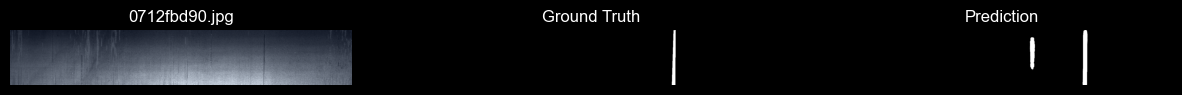

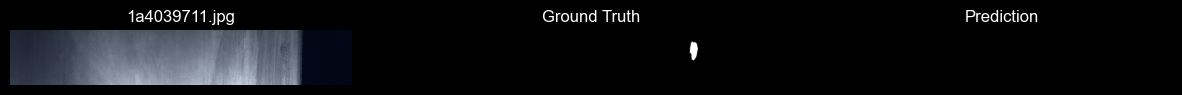

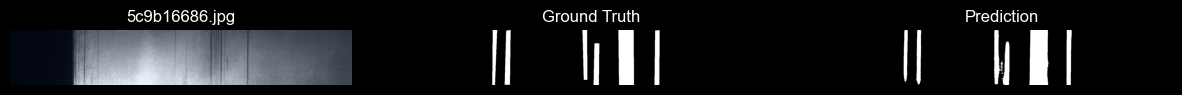

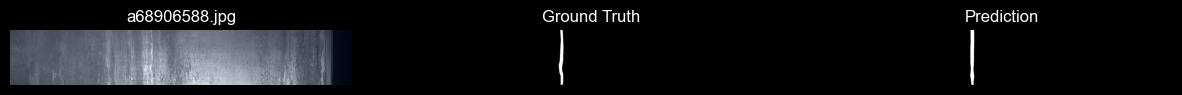

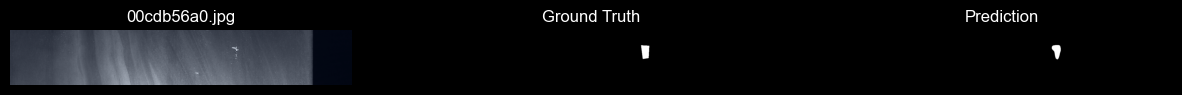

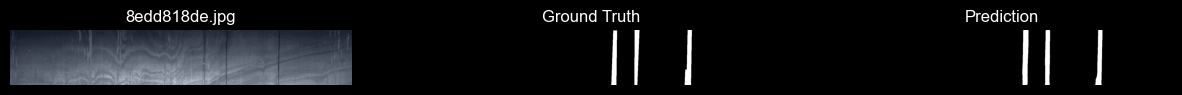

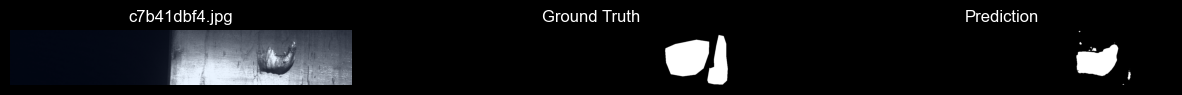

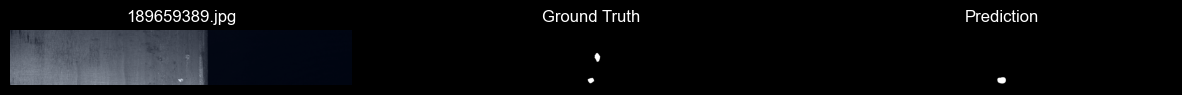

In [28]:
visualize_predictions(model, val_ds, device="cpu")

## ROI Extraction

In [47]:
import numpy as np
import cv2
from sklearn.cluster import DBSCAN


class RoIExtractor:
    def __init__(self, eps=3, min_samples=20, min_cluster_size=50):
        self.eps = eps
        self.min_samples = min_samples
        self.min_cluster_size = min_cluster_size

    # =========================
    # 1. Convert multi-class → binary mask per class
    # =========================
    def get_binary_mask(self, multi_mask, class_id):
        """
        multi_mask: (C, H, W)
        return: (H, W)
        """
        return (multi_mask[class_id] > 0.5).astype(np.uint8)

    # =========================
    # 2. DBSCAN lọc nhiễu
    # =========================
    def dbscan_filter(self, binary_mask):
        points = np.column_stack(np.where(binary_mask > 0))

        if len(points) == 0:
            return binary_mask

        clustering = DBSCAN(eps=self.eps, min_samples=self.min_samples).fit(points)
        labels = clustering.labels_

        filtered_mask = np.zeros_like(binary_mask)

        for label in set(labels):
            if label == -1:
                continue

            cluster_points = points[labels == label]

            if len(cluster_points) >= self.min_cluster_size:
                filtered_mask[cluster_points[:, 0], cluster_points[:, 1]] = 1

        return filtered_mask

    # =========================
    # 3. Extract bounding boxes
    # =========================
    def extract_bboxes(self, mask):
        num_labels, labels = cv2.connectedComponents(mask)

        bboxes = []

        for i in range(1, num_labels):
            ys, xs = np.where(labels == i)

            if len(xs) == 0:
                continue

            x_min, x_max = xs.min(), xs.max()
            y_min, y_max = ys.min(), ys.max()

            bboxes.append((x_min, y_min, x_max, y_max))

        return bboxes

    # =========================
    # 4. Crop + padding
    # =========================
    def crop_patch(self, image, bbox, size=128):
        x_min, y_min, x_max, y_max = bbox

        crop = image[y_min:y_max, x_min:x_max]
        h, w = crop.shape[:2]

        if h == 0 or w == 0:
            return None

        scale = size / max(h, w)
        crop = cv2.resize(crop, (int(w * scale), int(h * scale)))

        pad_h = size - crop.shape[0]
        pad_w = size - crop.shape[1]

        top = pad_h // 2
        bottom = pad_h - top
        left = pad_w // 2
        right = pad_w - left

        crop = cv2.copyMakeBorder(
            crop, top, bottom, left, right,
            cv2.BORDER_CONSTANT, value=0
        )

        return crop

    # =========================
    # 5. FULL PIPELINE
    # =========================
    def extract_rois(self, multi_mask, image=None):
        """
        multi_mask: (C, H, W)
        image: (H, W, 3)
        """
        results = []

        num_classes = multi_mask.shape[0]

        for class_id in range(num_classes):

            # 1. binary mask
            binary_mask = self.get_binary_mask(multi_mask, class_id)

            # 2. remove noise (DBSCAN)
            clean_mask = self.dbscan_filter(binary_mask)

            # 3. bounding boxes
            bboxes = self.extract_bboxes(clean_mask)

            for bbox in bboxes:
                roi = {
                    "class_id": class_id,
                    "bbox": bbox,
                    "mask": clean_mask
                }

                # 4. crop patch
                if image is not None:
                    patch = self.crop_patch(image, bbox)
                    roi["patch"] = patch

                results.append(roi)

        return results

In [138]:
import matplotlib.pyplot as plt
import torch
import numpy as np


@torch.no_grad()
def visualize_batch_predictions(model, images, masks, device, k=4, thr=0.5):
    """
    images: (B, 3, H, W)
    masks:  (B, C, H, W)
    """

    model.eval()

    images = images.to(device)

    # forward
    outputs = torch.sigmoid(model(images))  # (B, C, H, W)

    # chọn random k ảnh trong batch
    B = images.shape[0]
    idxs = np.random.choice(B, size=min(k, B), replace=False)

    for i in idxs:

        img = images[i].cpu()
        mask = masks[i].cpu()
        pred = outputs[i].cpu()

        # ===== convert =====
        img_np = img.permute(1, 2, 0).numpy()
        mask_np = mask.permute(1, 2, 0).numpy()
        pred_np = pred.permute(1, 2, 0).numpy()

        pred_bin = (pred_np > thr).astype(np.uint8)

        # ===== normalize image =====
        img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)

        # ===== plot =====
        fig, axs = plt.subplots(1, 3, figsize=(15, 5))

        # Image
        axs[0].imshow(img_np)
        axs[0].set_title(f"Image {i}")
        axs[0].axis("off")

        # Ground Truth (gộp các class)
        axs[1].imshow(mask_np.max(-1), cmap="gray")
        axs[1].set_title("Ground Truth")
        axs[1].axis("off")

        # Prediction
        axs[2].imshow(pred_bin.max(-1), cmap="gray")
        axs[2].set_title("Prediction")
        axs[2].axis("off")

        plt.tight_layout()
        plt.show()

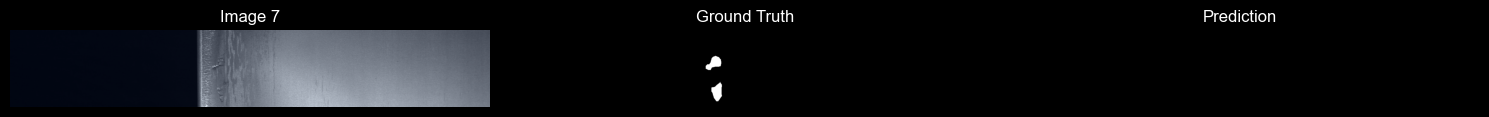

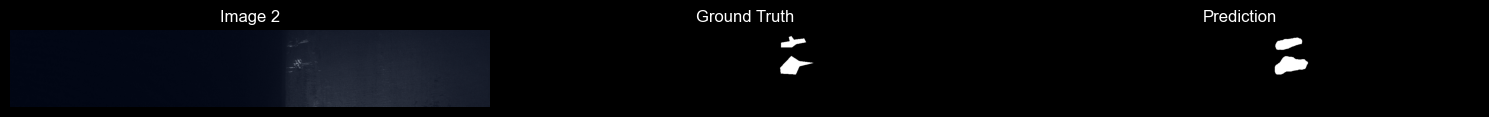

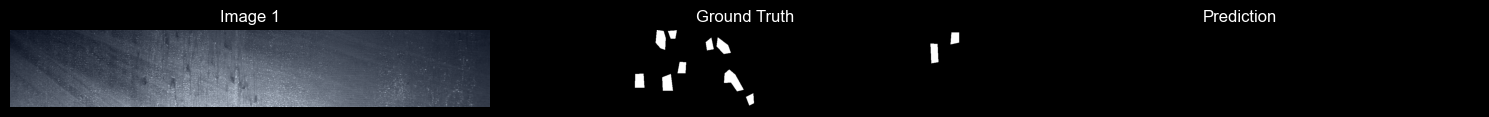

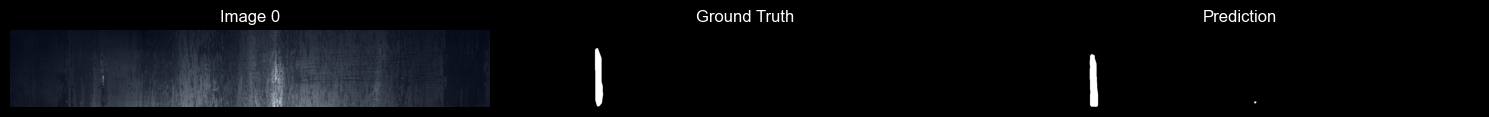

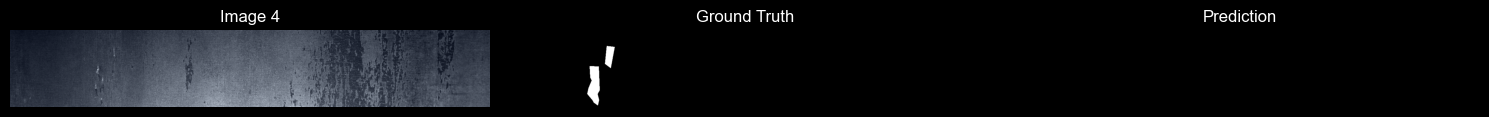

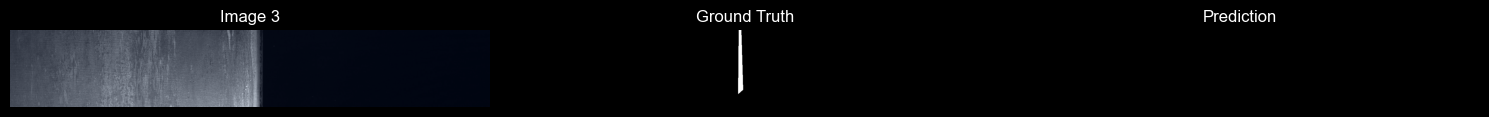

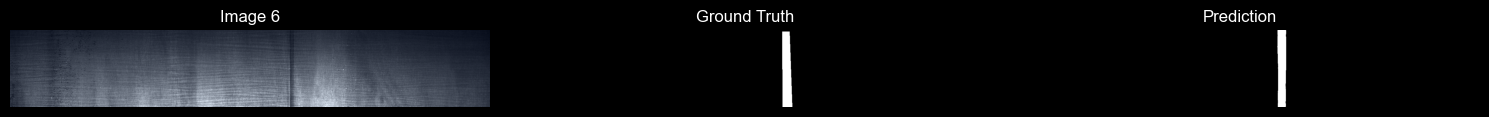

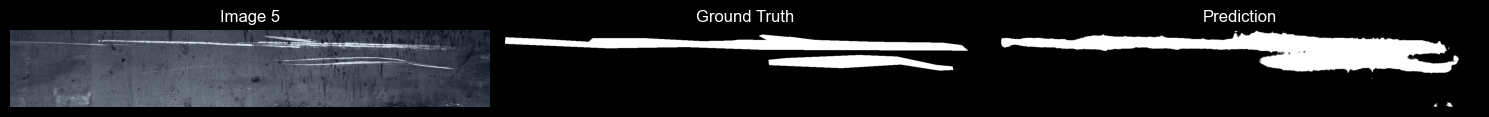

In [141]:
visualize_batch_predictions(model, batch['image'], batch['mask'], device='cpu', k=8)

In [ ]:
import torch
from pathlib import Path
import cv2

extractor = RoIExtractor(eps=5, min_samples=20, min_cluster_size=50)
save_dir = Path("New Dataset after")
save_dir.mkdir(exist_ok=True)

model.eval()

with torch.no_grad():
    for batch_idx, (images, _) in enumerate(test_loader):

        images = images.to(device)  # (B, 3, H, W)

        outputs = model(images)  # (B, C, H, W)

        # convert to probability
        probs = torch.softmax(outputs, dim=1)

        for b in range(images.shape[0]):

            # =========================
            # 1. lấy mask
            # =========================
            multi_mask = probs[b].cpu().numpy()  # (C, H, W)

            # =========================
            # 2. lấy ảnh gốc
            # =========================
            img = images[b].cpu().numpy().transpose(1, 2, 0)

            # normalize lại nếu cần
            # img = (img * 255).astype("uint8")

            # =========================
            # 3. extract RoIs
            # =========================
            rois = extractor.extract_rois(multi_mask, image=img)

            # =========================
            # 4. save patch
            # =========================
            for i, roi in enumerate(rois):

                patch = roi.get("patch", None)

                if patch is None:
                    continue

                class_id = roi["class_id"]

                # tạo folder theo class
                class_dir = save_dir / f"class_{class_id}"
                class_dir.mkdir(exist_ok=True)

                filename = class_dir / f"img_{batch_idx}_{b}_{i}.png"

                cv2.imwrite(str(filename), patch)

Image 0: 1 patches


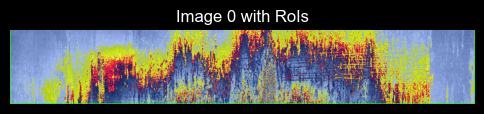

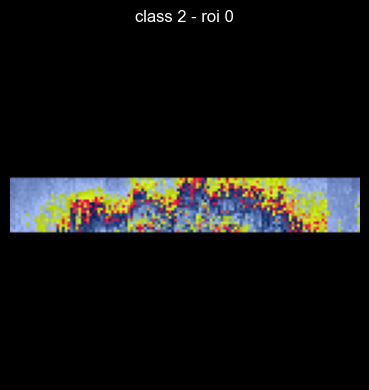

Image 1: 1 patches


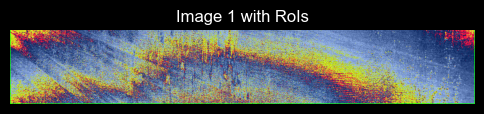

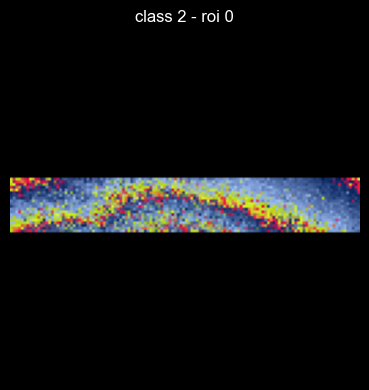

Image 2: 1 patches


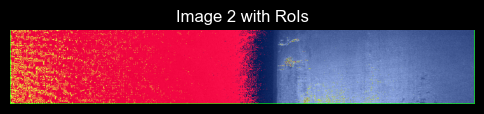

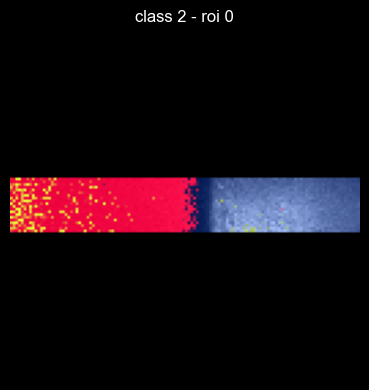

Image 3: 1 patches


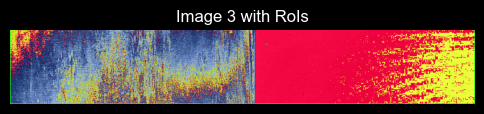

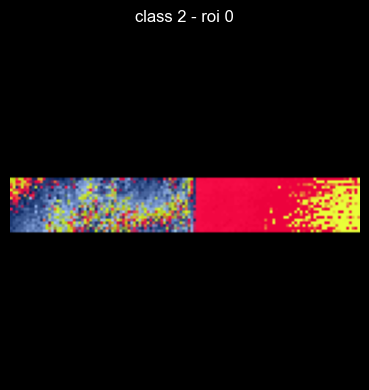

Image 4: 1 patches


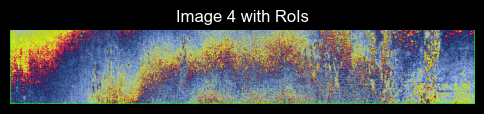

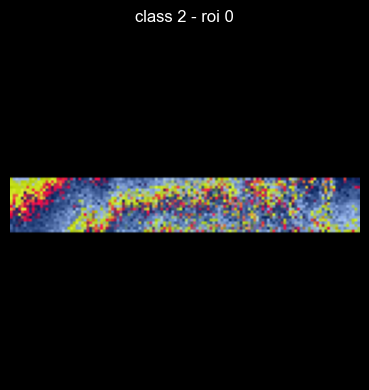

Image 5: 1 patches


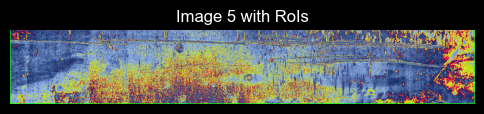

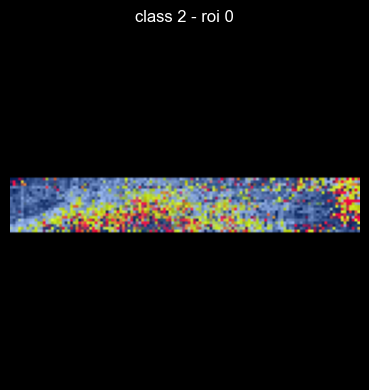

Image 6: 1 patches


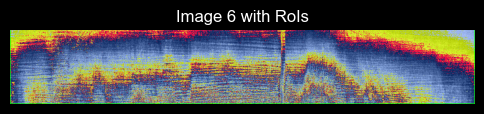

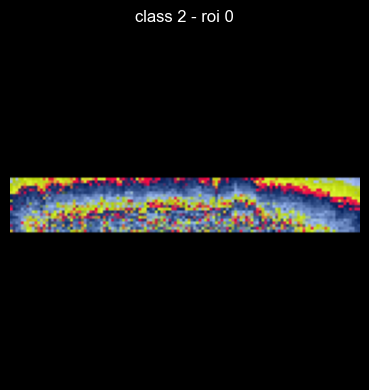

Image 7: 1 patches


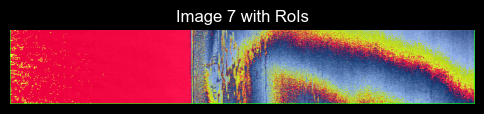

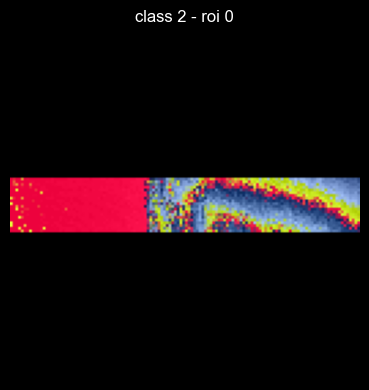

In [143]:
# import matplotlib.pyplot as plt
# import numpy as np
# import cv2
# from pathlib import Path
#
# extractor = RoIExtractor(eps=5, min_samples=20, min_cluster_size=50)
#
# save_dir = Path("patches")
# save_dir.mkdir(exist_ok=True)
#
# for b in range(images.shape[0]):
#
#     # =========================
#     # 1. lấy mask
#     # =========================
#     multi_mask = probs[b].cpu().numpy()  # (C, H, W)
#
#     # =========================
#     # 2. lấy ảnh gốc
#     # =========================
#     img = images[b].cpu().numpy().transpose(1, 2, 0)
#     img = (img * 255).astype("uint8")
#
#     # =========================
#     # 3. extract RoIs
#     # =========================
#     rois = extractor.extract_rois(multi_mask, image=img)
#
#     print(f"Image {b}: {len(rois)} patches")
#
#     # =========================
#     # 4. visualize bbox trên ảnh gốc
#     # =========================
#     img_vis = img.copy()
#
#     for roi in rois:
#         x1, y1, x2, y2 = roi["bbox"]
#         cv2.rectangle(img_vis, (x1, y1), (x2, y2), (0,255,0), 2)
#
#     plt.figure(figsize=(6,6))
#     plt.imshow(img_vis)
#     plt.title(f"Image {b} with RoIs")
#     plt.axis("off")
#     plt.show()
#
#     # =========================
#     # 5. lưu + gom patch để plot
#     # =========================
#     patches = []
#     titles = []
#
#     for i, roi in enumerate(rois):
#
#         patch = roi.get("patch", None)
#         if patch is None:
#             continue
#
#         class_id = roi["class_id"]
#
#         # save
#         class_dir = save_dir / f"class_{class_id}"
#         class_dir.mkdir(exist_ok=True)
#
#         filename = class_dir / f"img{b}_roi{i}.png"
#         cv2.imwrite(str(filename), patch)
#
#         # lưu để plot
#         patches.append(patch)
#         titles.append(f"class {class_id} - roi {i}")
#
#     # =========================
#     # 6. show patch dạng grid
#     # =========================
#     if len(patches) > 0:
#         cols = min(4, len(patches))
#         rows = int(np.ceil(len(patches) / cols))
#
#         plt.figure(figsize=(4*cols, 4*rows))
#
#         for idx, patch in enumerate(patches):
#             plt.subplot(rows, cols, idx+1)
#             plt.imshow(patch)
#             plt.title(titles[idx])
#             plt.axis("off")
#
#         plt.tight_layout()
#         plt.show()

In [30]:
import cv2
import numpy as np

In [35]:
imgpath = "/Users/thachphung/Documents/Graduation Project/Jupyter Notebook/tampak_depan_asli.png"
img = cv2.imread(imgpath)

In [36]:
height, width = 500, 500
imgResize = cv2.resize(img,(height,width), interpolation=cv2.INTER_AREA)

In [37]:
cv2.rectangle(imgResize,(300,250),(320,270),(255,0,0),2)
roi = imgResize[255:267, 305: 317]

In [38]:
cv2.imshow("resized", imgResize)
cv2.imshow("roi", roi)
cv2.waitKey(0)

48

## ROI

In [49]:
import numpy as np
import cv2
from sklearn.cluster import DBSCAN


class RoIExtractor:
    def __init__(self, eps=3, min_samples=20, min_cluster_size=50):
        self.eps = eps
        self.min_samples = min_samples
        self.min_cluster_size = min_cluster_size

    # =========================
    # 1. DBSCAN lọc nhiễu
    # =========================
    def dbscan_filter(self, binary_mask):
        points = np.column_stack(np.where(binary_mask > 0))

        if len(points) == 0:
            return binary_mask

        clustering = DBSCAN(eps=self.eps, min_samples=self.min_samples).fit(points)
        labels = clustering.labels_

        filtered_mask = np.zeros_like(binary_mask)

        for label in set(labels):
            if label == -1:
                continue

            cluster_points = points[labels == label]

            if len(cluster_points) >= self.min_cluster_size:
                filtered_mask[cluster_points[:, 0], cluster_points[:, 1]] = 1

        return filtered_mask

    # =========================
    # 2. Extract bounding boxes
    # =========================
    def extract_bboxes(self, mask):
        num_labels, labels = cv2.connectedComponents(mask)

        bboxes = []

        for i in range(1, num_labels):  # bỏ background
            ys, xs = np.where(labels == i)

            if len(xs) == 0:
                continue

            x_min, x_max = xs.min(), xs.max()
            y_min, y_max = ys.min(), ys.max()

            bboxes.append((x_min, y_min, x_max, y_max))

        return bboxes

    # =========================
    # 3. Crop + padding
    # =========================
    def crop_patch(self, image, bbox, size=128):
        x_min, y_min, x_max, y_max = bbox

        # ✅ FIX: +1 để không mất pixel cuối
        crop = image[y_min:y_max+1, x_min:x_max+1]

        h, w = crop.shape[:2]
        if h == 0 or w == 0:
            return None

        scale = size / max(h, w)
        crop = cv2.resize(crop, (int(w * scale), int(h * scale)))

        pad_h = size - crop.shape[0]
        pad_w = size - crop.shape[1]

        top = pad_h // 2
        bottom = pad_h - top
        left = pad_w // 2
        right = pad_w - left

        crop = cv2.copyMakeBorder(
            crop, top, bottom, left, right,
            cv2.BORDER_CONSTANT, value=0
        )

        return crop

    # =========================
    # 4. FULL PIPELINE (multi-class)
    # =========================
    def extract_rois(self, class_map, image=None):
        """
        class_map: (H, W) từ argmax
        image: (H, W, 3)
        """
        results = []
        num_classes = np.max(class_map) + 1

        for class_id in range(1, num_classes):  # bỏ background

            binary_mask = (class_map == class_id).astype(np.uint8)

            # lọc nhiễu
            clean_mask = self.dbscan_filter(binary_mask)

            # bbox
            bboxes = self.extract_bboxes(clean_mask)

            for bbox in bboxes:
                roi = {
                    "class_id": class_id,
                    "bbox": bbox
                }

                if image is not None:
                    patch = self.crop_patch(image, bbox)
                    roi["patch"] = patch

                results.append(roi)

        return results

In [75]:
import torch
import numpy as np
import cv2
from pathlib import Path

save_dir = Path("dataset_multilabel")
img_dir = save_dir / "images"
img_dir.mkdir(parents=True, exist_ok=True)

label_file = save_dir / "labels.txt"

# clear label file
open(label_file, "w").close()

model.eval()

THRESHOLD = 0.1  # ngưỡng multi-label

with torch.no_grad():
    for batch in test_loader:

        images = batch['image'].to(device)
        metas = batch['meta']

        outputs = model(images)  # (B, 4, H, W)
        probs = torch.softmax(outputs, dim=1)

        for b in range(images.shape[0]):

            img = images[b].cpu().numpy().transpose(1, 2, 0)
            img = (img - img.min()) / (img.max() - img.min() + 1e-6)
            img = (img * 255).astype("uint8")

            image_id = metas["image_id"][b]

            # dùng argmax để tìm vùng (ROI), KHÔNG dùng để tạo label
            class_map = torch.argmax(probs[b], dim=0).cpu().numpy()

            rois = extractor.extract_rois(class_map, image=img)

            for i, roi in enumerate(rois):

                patch = roi.get("patch", None)
                if patch is None:
                    continue

                if patch.mean() < 5:
                    continue

                x_min, y_min, x_max, y_max = roi["bbox"]

                # =========================
                # CROP MASK
                # =========================
                mask_roi = probs[b, :, y_min:y_max, x_min:x_max].cpu().numpy()

                # =========================
                # MULTI-LABEL
                # =========================
                class_scores = mask_roi.reshape(mask_roi.shape[0], -1).mean(axis=1)

                label = (class_scores > THRESHOLD).astype(int)

                # bỏ patch không có defect
                if label.sum() == 0:
                    continue

                # =========================
                # SAVE IMAGE
                # =========================
                filename = f"{image_id}_roi{i}.png"
                filepath = img_dir / filename

                cv2.imwrite(str(filepath), patch)

                # =========================
                # SAVE LABEL
                # =========================
                with open(label_file, "a") as f:
                    f.write(f"{filename} {' '.join(map(str, label))}\n")

## ROI UPDATE

In [119]:
import numpy as np
import cv2
from sklearn.cluster import DBSCAN


class RoIExtractor:

    def __init__(
        self,
        eps=3,
        min_samples=10,
        min_cluster_size=20,
        min_bbox_area=50,
        roi_size=224,
        padding=20,
        iou_threshold=0.5,
        top_k=5
    ):

        self.eps = eps
        self.min_samples = min_samples
        self.min_cluster_size = min_cluster_size

        self.min_bbox_area = min_bbox_area

        self.roi_size = roi_size
        self.padding = padding

        self.iou_threshold = iou_threshold
        self.top_k = top_k

    # ======================================================
    # 1. Morphology cleaning
    # ======================================================
    def morphology_clean(self, mask):

        kernel = np.ones((3, 3), np.uint8)

        mask = cv2.morphologyEx(
            mask.astype(np.uint8),
            cv2.MORPH_OPEN,
            kernel
        )

        mask = cv2.morphologyEx(
            mask,
            cv2.MORPH_CLOSE,
            kernel
        )

        return mask

    # ======================================================
    # 2. DBSCAN filter
    # ======================================================
    def dbscan_filter(self, binary_mask):

        points = np.column_stack(np.where(binary_mask > 0))

        if len(points) == 0:
            return binary_mask

        clustering = DBSCAN(
            eps=self.eps,
            min_samples=self.min_samples
        ).fit(points)

        labels = clustering.labels_

        filtered_mask = np.zeros_like(binary_mask)

        for label in set(labels):

            if label == -1:
                continue

            cluster_points = points[labels == label]

            if len(cluster_points) >= self.min_cluster_size:

                filtered_mask[
                    cluster_points[:, 0],
                    cluster_points[:, 1]
                ] = 1

        return filtered_mask

    # ======================================================
    # 3. Extract bbox
    # ======================================================
    def extract_bboxes(self, mask):

        num_labels, labels = cv2.connectedComponents(mask)

        bboxes = []

        H, W = mask.shape

        for i in range(1, num_labels):

            ys, xs = np.where(labels == i)

            if len(xs) == 0:
                continue

            x_min, x_max = xs.min(), xs.max()
            y_min, y_max = ys.min(), ys.max()

            # area filter
            area = (x_max - x_min) * (y_max - y_min)

            if area < self.min_bbox_area:
                continue

            # padding
            x_min = max(0, x_min - self.padding)
            y_min = max(0, y_min - self.padding)

            x_max = min(W - 1, x_max + self.padding)
            y_max = min(H - 1, y_max + self.padding)

            bboxes.append((x_min, y_min, x_max, y_max))

        return bboxes

    # ======================================================
    # 4. IoU
    # ======================================================
    def compute_iou(self, box1, box2):

        x1 = max(box1[0], box2[0])
        y1 = max(box1[1], box2[1])

        x2 = min(box1[2], box2[2])
        y2 = min(box1[3], box2[3])

        inter = max(0, x2 - x1) * max(0, y2 - y1)

        area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
        area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

        union = area1 + area2 - inter + 1e-6

        return inter / union

    # ======================================================
    # 5. NMS
    # ======================================================
    def nms(self, bboxes):

        if len(bboxes) == 0:
            return []

        areas = [
            (b[2] - b[0]) * (b[3] - b[1])
            for b in bboxes
        ]

        order = np.argsort(areas)[::-1]

        keep = []

        while len(order) > 0:

            idx = order[0]

            keep.append(bboxes[idx])

            remain = []

            for j in order[1:]:

                iou = self.compute_iou(
                    bboxes[idx],
                    bboxes[j]
                )

                if iou < self.iou_threshold:
                    remain.append(j)

            order = np.array(remain)

        return keep

    # ======================================================
    # 6. Crop ROI
    # ======================================================
    def crop_patch(self, image, bbox):

        x_min, y_min, x_max, y_max = bbox

        crop = image[
            y_min:y_max+1,
            x_min:x_max+1
        ]

        h, w = crop.shape[:2]

        if h == 0 or w == 0:
            return None

        scale = self.roi_size / max(h, w)

        crop = cv2.resize(
            crop,
            (
                int(w * scale),
                int(h * scale)
            )
        )

        pad_h = self.roi_size - crop.shape[0]
        pad_w = self.roi_size - crop.shape[1]

        top = pad_h // 2
        bottom = pad_h - top

        left = pad_w // 2
        right = pad_w - left

        crop = cv2.copyMakeBorder(
            crop,
            top,
            bottom,
            left,
            right,
            cv2.BORDER_CONSTANT,
            value=0
        )

        return crop

    # ======================================================
    # 7. Full pipeline
    # ======================================================
def extract_rois(
    self,
    prob_maps,
    image,
    roi_threshold=0.3
):

    results = []

    num_classes = prob_maps.shape[0]

    for class_id in range(num_classes):

        # =====================================
        # THRESHOLD PER CLASS
        # =====================================
        binary_mask = (
            prob_maps[class_id] > roi_threshold
        )

        binary_mask = np.asarray(
            binary_mask,
            dtype=np.uint8
        )

        binary_mask = np.ascontiguousarray(
            binary_mask
        )

        # =====================================
        # MORPHOLOGY
        # =====================================
        binary_mask = self.morphology_clean(
            binary_mask
        )

        # =====================================
        # DBSCAN
        # =====================================
        clean_mask = self.dbscan_filter(
            binary_mask
        )

        # =====================================
        # BBOX
        # =====================================
        bboxes = self.extract_bboxes(
            clean_mask
        )

        # =====================================
        # NMS
        # =====================================
        bboxes = self.nms(bboxes)

        # =====================================
        # SORT BY AREA
        # =====================================
        bboxes = sorted(
            bboxes,
            key=lambda b:
                (b[2]-b[0]) * (b[3]-b[1]),
            reverse=True
        )

        # top-k
        bboxes = bboxes[:self.top_k]

        # =====================================
        # SAVE ROI
        # =====================================
        for bbox in bboxes:

            patch = self.crop_patch(
                image,
                bbox
            )

            if patch is None:
                continue

            results.append({
                "class_id": class_id,
                "bbox": bbox,
                "patch": patch
            })

    return results

In [121]:
import torch
import numpy as np
import cv2
from pathlib import Path


save_dir = Path("dataset_multilabel_update")

img_dir = save_dir / "images"

img_dir.mkdir(
    parents=True,
    exist_ok=True
)

label_file = save_dir / "labels.txt"

open(label_file, "w").close()

# ============================================
# THRESHOLD
# ============================================
ROI_THRESHOLD = 0.4
LABEL_THRESHOLD = 0.4

model.eval()

with torch.no_grad():

    for batch in test_loader:

        images = batch["image"].to(device)
        metas = batch["meta"]

        # =====================================
        # SEGMENTATION OUTPUT
        # (B, 4, H, W)
        # =====================================
        outputs = model(images)

        # ✅ MULTI-LABEL SEGMENTATION
        probs = torch.sigmoid(outputs)

        for b in range(images.shape[0]):

            # =====================================
            # IMAGE
            # =====================================
            img = images[b].cpu().numpy()

            img = img.transpose(1, 2, 0)

            img = (
                img - img.min()
            ) / (
                img.max() - img.min() + 1e-6
            )

            img = (img * 255).astype("uint8")

            image_id = metas["image_id"][b]

            # =====================================
            # PROBABILITY MAPS
            # (4, H, W)
            # =====================================
            prob_maps = probs[b].cpu().numpy()

            # =====================================
            # ROI EXTRACTION
            # =====================================
            rois = extractor.extract_rois(
                prob_maps=prob_maps,
                image=img,
                roi_threshold=ROI_THRESHOLD
            )

            # =====================================
            # SAVE ROI
            # =====================================
            for i, roi in enumerate(rois):

                patch = roi["patch"]

                x_min, y_min, x_max, y_max = roi["bbox"]

                # =================================
                # ROI probability
                # =================================
                mask_roi = prob_maps[
                    :,
                    y_min:y_max,
                    x_min:x_max
                ]

                # =================================
                # MULTI-LABEL SCORE
                # dùng MAX
                # =================================
                class_scores = mask_roi.reshape(
                    mask_roi.shape[0],
                    -1
                ).max(axis=1)

                # =================================
                # MULTI-LABEL VECTOR
                # =================================
                label = (
                    class_scores > LABEL_THRESHOLD
                ).astype(int)

                # remove empty ROI
                if label.sum() == 0:
                    continue

                # =================================
                # SAVE IMAGE
                # =================================
                filename = f"{image_id}_roi{i}.png"

                filepath = img_dir / filename

                cv2.imwrite(
                    str(filepath),
                    patch
                )

                # =================================
                # SAVE LABEL
                # =================================
                with open(label_file, "a") as f:

                    f.write(
                        f"{filename} "
                        f"{' '.join(map(str, label))}\n"
                    )

KeyboardInterrupt: 

# Multi-label Classification

## Libraries

In [81]:
import torch
import torchvision
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from torchvision import models

In [77]:
DATA_DIR = 'dataset_multilabel'


## Dataset

In [78]:
class MultiLabelDataset(Dataset):
    def __init__(self, root):
        self.root = Path(root)
        self.samples = []

        with open(self.root / "labels.txt") as f:
            for line in f:
                parts = line.strip().split()
                img_name = parts[0]
                label = list(map(int, parts[1:]))

                self.samples.append((img_name, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_name, label = self.samples[idx]

        img = cv2.imread(str(self.root / "images" / img_name))
        img = cv2.resize(img, (224, 224))

        img = torch.tensor(img).permute(2, 0, 1).float() / 255.

        label = torch.tensor(label, dtype=torch.float32)

        return img, label

## Dataloader

In [79]:
dataset = MultiLabelDataset(DATA_DIR)

In [82]:
train_data, val_data = train_test_split(dataset, test_size=0.2, random_state=42)

In [83]:
train_loader = DataLoader(dataset=train_data, batch_size=8, shuffle=True, num_workers=2)
val_loader = DataLoader(dataset=val_data, batch_size=8, shuffle=True, num_workers=2)

In [84]:
batch = next(iter(train_loader))

In [89]:
batch[0].shape

torch.Size([8, 3, 224, 224])

## Model

In [90]:
class ResNetMultiLabel(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        self.backbone = models.resnet50(pretrained=True)
        in_features = self.backbone.fc.in_features

        self.backbone.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

In [92]:
from torchinfo import summary
model = ResNetMultiLabel()
summary(model, input_size=[8, 3, 224, 224])

Layer (type:depth-idx)                        Output Shape              Param #
ResNetMultiLabel                              [8, 4]                    --
├─ResNet: 1-1                                 [8, 4]                    --
│    └─Conv2d: 2-1                            [8, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                       [8, 64, 112, 112]         128
│    └─ReLU: 2-3                              [8, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                         [8, 64, 56, 56]           --
│    └─Sequential: 2-5                        [8, 256, 56, 56]          --
│    │    └─Bottleneck: 3-1                   [8, 256, 56, 56]          75,008
│    │    └─Bottleneck: 3-2                   [8, 256, 56, 56]          70,400
│    │    └─Bottleneck: 3-3                   [8, 256, 56, 56]          70,400
│    └─Sequential: 2-6                        [8, 512, 28, 28]          --
│    │    └─Bottleneck: 3-4                   [8, 512, 28, 28]          379,392